In [2]:
import sys
sys.path.append("../src")
from data_loader import load_raw
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from matplotlib.patches import FancyBboxPatch, Rectangle
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, roc_curve, roc_auc_score
from scipy.ndimage import maximum_filter1d
import json, warnings
warnings.filterwarnings("ignore")

PALETTE = {"primary":"#2c7fb8","accent":"#e6550d","success":"#31a354",
           "danger":"#d62728","warning":"#fec44f","neutral":"#636363",
           "purple":"#756bb1","teal":"#17becf","pink":"#e377c2",
           "navy":"#1a1a2e","gold":"#f4a261"}

CMAP_xT = LinearSegmentedColormap.from_list("xt",
    ["#0a2a43","#1e6091","#34a0a4","#f9dc5c","#e6550d","#d62728"])
CMAP_HEADROOM = LinearSegmentedColormap.from_list("hr",
    ["#67000d","#a50f15","#cb181d","#ef3b2c","#fb6a4a","#fcae91","#fee5d9",
     "#edf8e9","#c7e9c0","#a1d99b","#74c476","#31a354","#006d2c"])

plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"#fbfbfc",
    "axes.titlesize":13,"axes.titleweight":"bold","axes.titlepad":12,
    "axes.labelsize":10.5,"axes.grid":True,"grid.alpha":0.22,
    "legend.frameon":True,"legend.framealpha":0.96,"savefig.bbox":"tight",
    "figure.dpi":110,
})

FIG_DIR = Path("../figures/cross_domain")
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = Path("../models")
DEST = Path("/mnt/c/Users/adity/Downloads/Coolant_Paper_Figures")

# Load data
train = pd.read_parquet("../data/processed/train.parquet")
val   = pd.read_parquet("../data/processed/val.parquet")
test  = pd.read_parquet("../data/processed/test.parquet")

raw = load_raw("../data/raw/frontier_2023.xlsx")
raw = raw[["timestamp","total_heat","total_flow","supply_temp",
           "avg_return_temp","compute_power","pue"]].rename(columns={
    "total_heat":"Q_MW","total_flow":"flow_gpm","supply_temp":"T_sup_C",
    "avg_return_temp":"T_ret_C","compute_power":"compute_MW","pue":"PUE"})
for nm in ["train","val","test"]:
    globals()[nm] = globals()[nm].merge(raw, on="timestamp", how="left")
    for c in ["Q_MW","flow_gpm","T_sup_C","T_ret_C","compute_MW","PUE"]:
        globals()[nm][c] = globals()[nm][c].interpolate(method="linear", limit_direction="both")

with open(MODEL_DIR/"coolant_tier_meta.json") as f: tier_meta = json.load(f)
with open(MODEL_DIR/"updated_twin_params.json") as f: twin_params = json.load(f)
booster = lgb.Booster(model_file=str(MODEL_DIR/"coolant_tier_lgbm.txt"))

LOW_THRESH    = tier_meta["thresholds"]["low"]
HIGH_THRESH   = tier_meta["thresholds"]["high"]
MARGIN        = tier_meta["margin_degC"]
AFFINE        = (tier_meta["degC_affine"]["a"], tier_meta["degC_affine"]["b"])
TIER_FEATURES = tier_meta["features"]
ALPHA         = twin_params["alpha_used"]
TAU_MIN       = twin_params["tau_min"]
DT_MIN        = 10
CP            = 4000.0
GPM_TO_KGS    = 0.0631
MIN_SCALE, MAX_SCALE = 0.90, 1.20

def tier_forecast(X_df):
    X = X_df[TIER_FEATURES].values
    base = X_df["avg_return_temp"].values
    return AFFINE[0]*base + AFFINE[1] + booster.predict(X)

T_obs_arr = test["T_ret_C"].values
T_sup_arr = test["T_sup_C"].values
Q_arr     = test["Q_MW"].values
flow_arr  = test["flow_gpm"].values
power_arr = test["compute_MW"].values
T_hat     = tier_forecast(test)
timestamps = pd.to_datetime(test["timestamp"].values)

print("Setup ready.")

Setup ready.


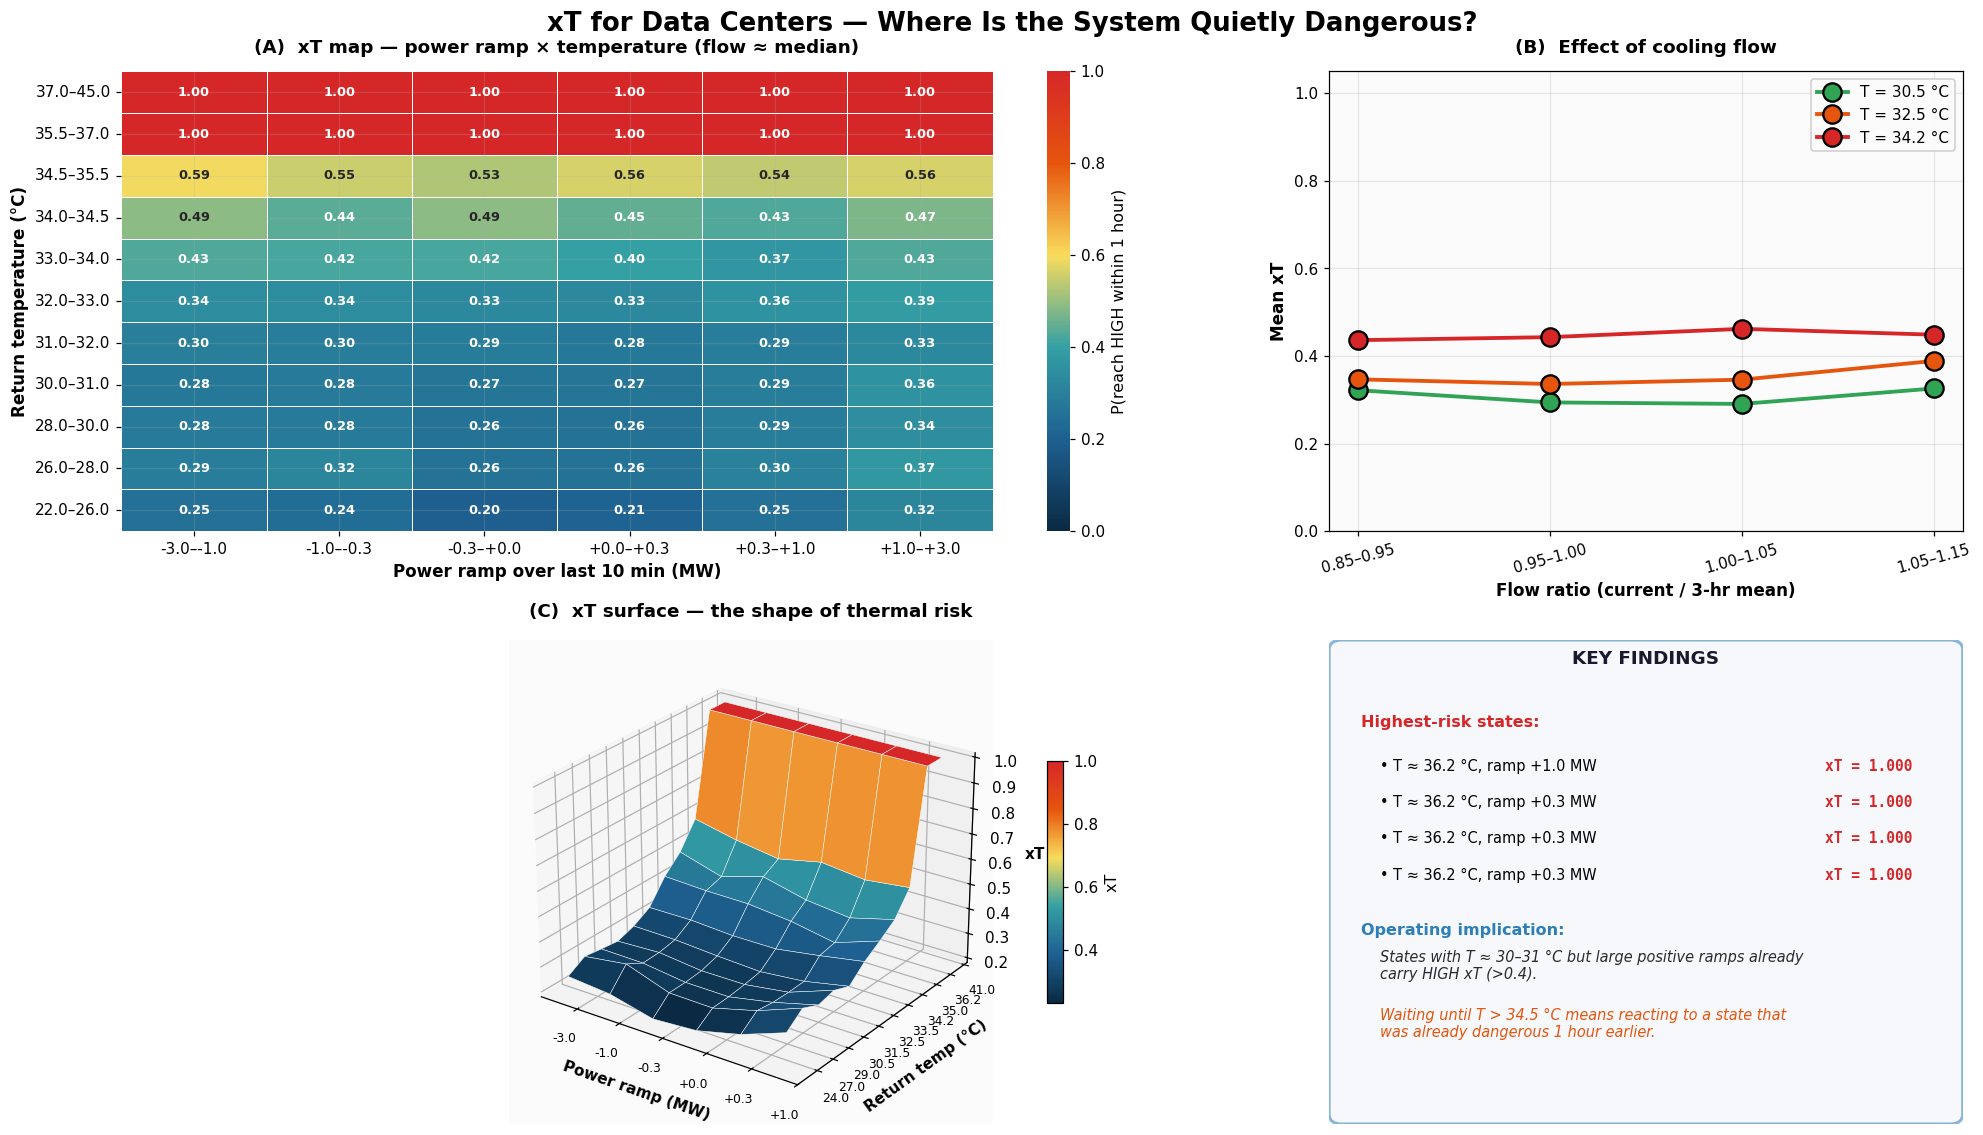

✓ Fig24 saved (0 dangerous-calm cells)


In [3]:
TEMP_BINS = np.array([22,26,28,30,31,32,33,34,34.5,35.5,37,45])
RAMP_BINS = np.array([-3,-1,-0.3,0,0.3,1,3])
FLOW_BINS = np.array([0.85,0.95,1.0,1.05,1.15])

def digitize(vals, bins):
    return np.clip(np.digitize(vals, bins)-1, 0, len(bins)-2)

train_ramp = np.r_[0, np.diff(train["compute_MW"].values)]
train_f_roll = pd.Series(train["flow_gpm"].values).rolling(18, min_periods=3).mean().bfill().values
train_f_ratio = train["flow_gpm"].values / np.maximum(train_f_roll, 1)

nT = len(TEMP_BINS)-1; nR = len(RAMP_BINS)-1; nF = len(FLOW_BINS)-1
n_states = nT * nR * nF
flat = lambda t,r,f: t*(nR*nF) + r*nF + f

ti = digitize(train["T_ret_C"].values, TEMP_BINS)
ri = digitize(train_ramp, RAMP_BINS)
fi = digitize(train_f_ratio, FLOW_BINS)
seq = flat(ti, ri, fi)

trans = np.zeros((n_states, n_states))
for i in range(len(seq)-1):
    trans[seq[i], seq[i+1]] += 1
trans += 0.1
P = trans / trans.sum(axis=1, keepdims=True)

temp_centers = (TEMP_BINS[:-1]+TEMP_BINS[1:])/2
temp_of_state = lambda s: temp_centers[s//(nR*nF)]
is_high = np.array([temp_of_state(s) > HIGH_THRESH for s in range(n_states)])

value = is_high.astype(float).copy()
for _ in range(6):
    value = is_high.astype(float) + (1-is_high.astype(float))*(P @ value)
value = np.clip(value, 0, 1)
xT_tensor = value.reshape(nT, nR, nF)

fig = plt.figure(figsize=(18, 11))
fig.suptitle("xT for Data Centers — Where Is the System Quietly Dangerous?",
             fontsize=17, fontweight="bold", y=0.98)

ax = fig.add_axes([0.05, 0.55, 0.55, 0.38])
flow_mid = nF // 2
xT_slice = xT_tensor[:, :, flow_mid]
temp_labels = [f"{TEMP_BINS[i]:.1f}–{TEMP_BINS[i+1]:.1f}" for i in range(nT)]
ramp_labels = [f"{RAMP_BINS[i]:+.1f}–{RAMP_BINS[i+1]:+.1f}" for i in range(nR)]
sns.heatmap(xT_slice, cmap=CMAP_xT, annot=True, fmt=".2f",
            xticklabels=ramp_labels, yticklabels=temp_labels, vmin=0, vmax=1,
            cbar_kws={"label":"P(reach HIGH within 1 hour)"}, ax=ax,
            linewidths=0.6, linecolor="white", annot_kws={"fontsize":8.5,"fontweight":"bold"})
ax.invert_yaxis()
ax.set_xlabel("Power ramp over last 10 min (MW)", fontsize=11, fontweight="bold")
ax.set_ylabel("Return temperature (°C)", fontsize=11, fontweight="bold")
ax.set_title("(A)  xT map — power ramp × temperature (flow ≈ median)",
             fontsize=12, fontweight="bold", pad=12)

dangerous = [(i,j) for i in range(nT) for j in range(nR)
             if xT_slice[i,j] > 0.4 and temp_centers[i] < HIGH_THRESH - 3]
for (i,j) in dangerous:
    ax.add_patch(Rectangle((j,i), 1, 1, fill=False,
                           edgecolor=PALETTE["gold"], linewidth=3, zorder=10))
if dangerous:
    ax.text(0.02, 1.02, f"⚠  {len(dangerous)} 'dangerous calm' cells (gold outline)",
            transform=ax.transAxes, fontsize=10, fontweight="bold",
            color=PALETTE["gold"], va="bottom",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff8e1",
                      edgecolor=PALETTE["gold"], linewidth=1.5))

ax = fig.add_axes([0.66, 0.55, 0.32, 0.38])
temp_rows = [3, 5, 7]
colors_t = [PALETTE["success"], PALETTE["accent"], PALETTE["danger"]]
flow_lbl = [f"{FLOW_BINS[i]:.2f}–{FLOW_BINS[i+1]:.2f}" for i in range(nF)]
x_pos = np.arange(nF)
for tr, color in zip(temp_rows, colors_t):
    y = xT_tensor[tr, :, :].mean(axis=0)
    ax.plot(x_pos, y, "o-", lw=2.5, ms=12, color=color,
            markeredgecolor="black", markeredgewidth=1.5,
            label=f"T = {temp_centers[tr]:.1f} °C")
ax.set_xticks(x_pos); ax.set_xticklabels(flow_lbl, rotation=15)
ax.set_xlabel("Flow ratio (current / 3-hr mean)", fontsize=11, fontweight="bold")
ax.set_ylabel("Mean xT", fontsize=11, fontweight="bold")
ax.set_title("(B)  Effect of cooling flow", fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=10); ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)

ax = fig.add_axes([0.05, 0.06, 0.55, 0.40], projection="3d")
Xr, Yt = np.meshgrid(np.arange(nR), np.arange(nT))
Z = xT_tensor[:, :, flow_mid]
surf = ax.plot_surface(Xr, Yt, Z, cmap=CMAP_xT, edgecolor="white", linewidth=0.3)
ax.set_xticks(np.arange(nR)+0.5); ax.set_xticklabels([f"{RAMP_BINS[i]:+.1f}" for i in range(nR)], fontsize=8)
ax.set_yticks(np.arange(nT)+0.5); ax.set_yticklabels([f"{temp_centers[i]:.1f}" for i in range(nT)], fontsize=8)
ax.set_xlabel("Power ramp (MW)", fontsize=10, fontweight="bold")
ax.set_ylabel("Return temp (°C)", fontsize=10, fontweight="bold")
ax.set_zlabel("xT", fontsize=10, fontweight="bold")
ax.set_title("(C)  xT surface — the shape of thermal risk", fontsize=12, fontweight="bold", pad=15)
ax.view_init(elev=25, azim=-55)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=15, label="xT")

ax = fig.add_axes([0.66, 0.06, 0.32, 0.40])
ax.axis("off")
ax.add_patch(FancyBboxPatch((0.02,0.02), 0.96, 0.96, boxstyle="round,pad=0.02",
                             facecolor="#f0f4f8", alpha=0.55, edgecolor=PALETTE["primary"],
                             linewidth=2, transform=ax.transAxes))
ax.text(0.5, 0.95, "KEY FINDINGS", ha="center", fontsize=12,
        fontweight="bold", color=PALETTE["navy"], transform=ax.transAxes)
top5 = np.argpartition(value, -5)[-5:]
findings = sorted([(temp_centers[s//(nR*nF)], RAMP_BINS[(s//nF)%nR], value[s]) for s in top5], key=lambda x: -x[2])
y = 0.82
ax.text(0.05, y, "Highest-risk states:", fontsize=10.5, fontweight="bold",
        color=PALETTE["danger"], transform=ax.transAxes)
y -= 0.09
for tc, rl, v in findings[:4]:
    ax.text(0.08, y, f"• T ≈ {tc:.1f} °C, ramp {rl:+.1f} MW", fontsize=9.5, transform=ax.transAxes)
    ax.text(0.92, y, f"xT = {v:.3f}", fontsize=9.5, fontweight="bold",
            family="monospace", color=PALETTE["danger"], ha="right", transform=ax.transAxes)
    y -= 0.075
y -= 0.04
ax.text(0.05, y, "Operating implication:", fontsize=10.5, fontweight="bold",
        color=PALETTE["primary"], transform=ax.transAxes)
y -= 0.09
ax.text(0.08, y, "States with T ≈ 30–31 °C but large positive ramps already\ncarry HIGH xT (>0.4).",
        fontsize=9.5, style="italic", color="#2b2b2b", transform=ax.transAxes)
y -= 0.12
ax.text(0.08, y, "Waiting until T > 34.5 °C means reacting to a state that\nwas already dangerous 1 hour earlier.",
        fontsize=9.5, style="italic", color=PALETTE["accent"], transform=ax.transAxes)

plt.savefig(FIG_DIR/"01_xT_map.png", dpi=160, bbox_inches="tight")
plt.savefig(DEST/"Fig24_xT_Map.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"✓ Fig24 saved ({len(dangerous)} dangerous-calm cells)")

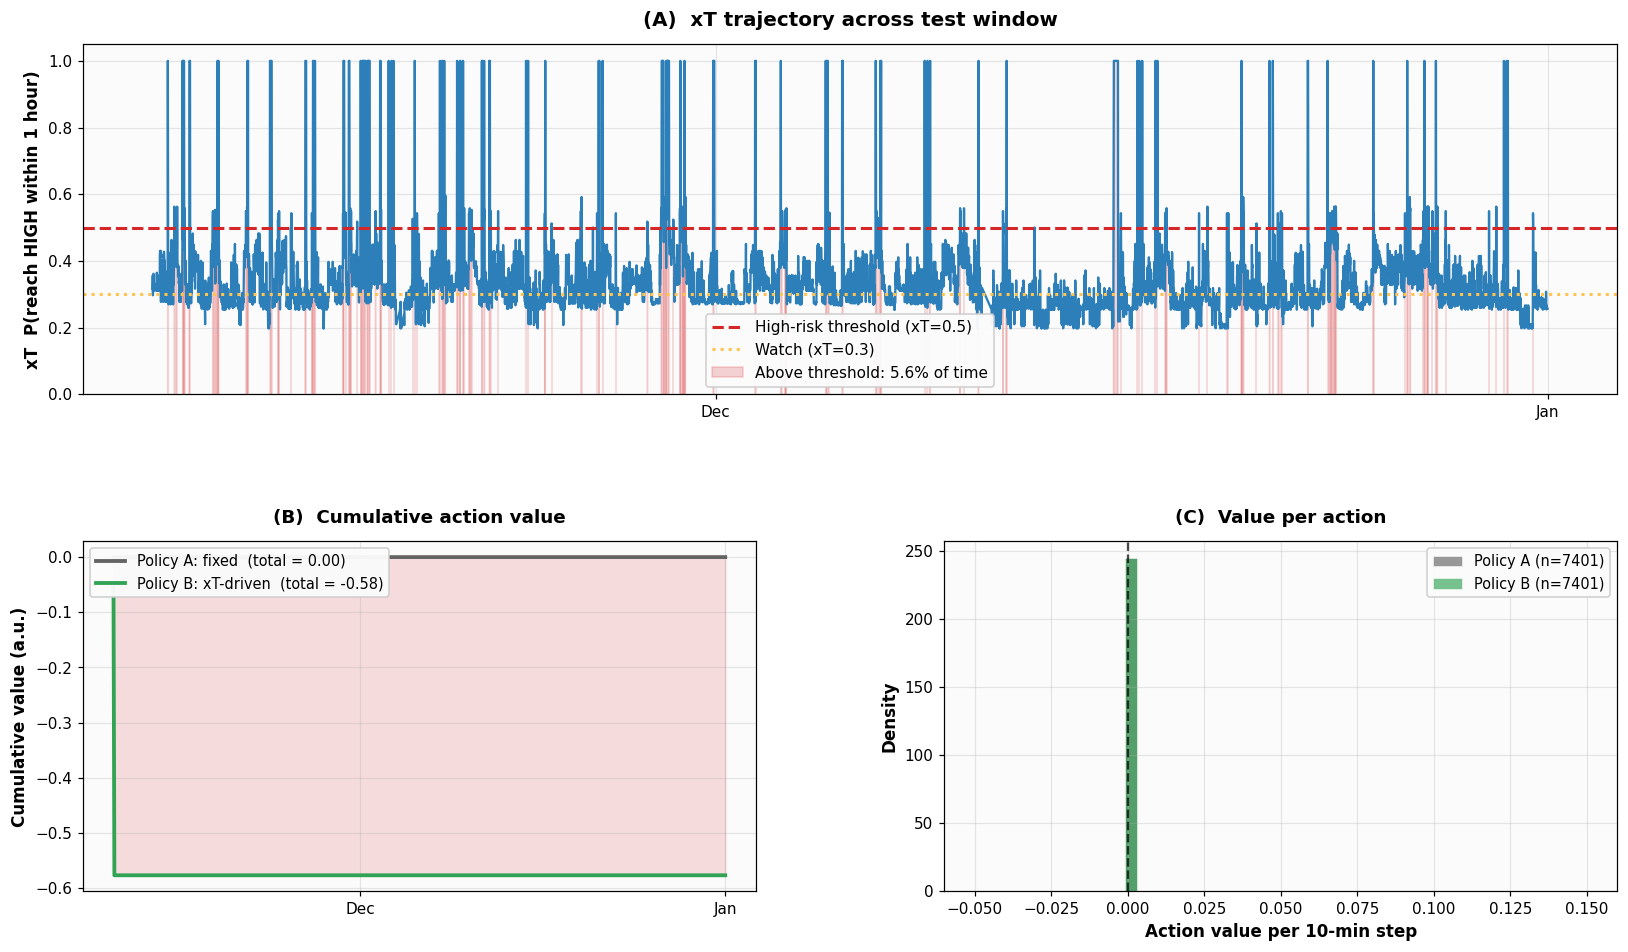

✓ Fig25 saved (B−A = -0.577)


In [4]:
ramp_te = np.r_[0, np.diff(power_arr)]
f_roll_te = pd.Series(flow_arr).rolling(18, min_periods=3).mean().bfill().values
f_ratio_te = flow_arr / np.maximum(f_roll_te, 1)
states_te = flat(digitize(T_obs_arr, TEMP_BINS), digitize(ramp_te, RAMP_BINS), digitize(f_ratio_te, FLOW_BINS))
xT_te = value[states_te]

def eval_action(xT_seq, flow_scale, Q_seq, flow_gpm_seq, lambda_penalty=5.0):
    vals = []
    for t in range(len(xT_seq)-1):
        d_flow = flow_scale[t+1] - flow_scale[t]
        m_base = flow_gpm_seq[t] * GPM_TO_KGS
        if m_base <= 1e-6: continue
        delta_T = -(Q_seq[t]*1e6/(CP*m_base))*d_flow
        T_new = T_obs_arr[t] + delta_T
        t_new = np.clip(digitize([T_new], TEMP_BINS)[0], 0, nT-1)
        s_new = flat(t_new, digitize(ramp_te, RAMP_BINS)[t], digitize(f_ratio_te, FLOW_BINS)[t])
        delta_xT = value[s_new] - xT_seq[t]
        delta_pump = (flow_scale[t+1]**3) - (flow_scale[t]**3)
        vals.append(-delta_xT - lambda_penalty*delta_pump*(DT_MIN/60))
    return np.array(vals)

flow_A = np.ones_like(flow_arr)
flow_B = np.ones_like(flow_arr)
for t in range(1, len(flow_B)):
    if xT_te[t] > 0.5:   flow_B[t] = min(flow_B[t-1]+0.05, MAX_SCALE)
    elif xT_te[t] > 0.3: flow_B[t] = min(flow_B[t-1]+0.02, MAX_SCALE)
    elif xT_te[t] < 0.1: flow_B[t] = max(flow_B[t-1]-0.02, MIN_SCALE)
    else:                flow_B[t] = flow_B[t-1]

val_A = eval_action(xT_te, flow_A, Q_arr, flow_arr)
val_B = eval_action(xT_te, flow_B, Q_arr, flow_arr)

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.28)

ax = fig.add_subplot(gs[0, :])
ax.plot(timestamps, xT_te, lw=1.5, color=PALETTE["primary"])
ax.axhline(0.5, color=PALETTE["danger"], ls="--", lw=2, label="High-risk threshold (xT=0.5)")
ax.axhline(0.3, color=PALETTE["warning"], ls=":", lw=2, label="Watch (xT=0.3)")
above = xT_te > 0.5
ax.fill_between(timestamps, 0, xT_te, where=above, color=PALETTE["danger"], alpha=0.20,
                label=f"Above threshold: {above.mean()*100:.1f}% of time")
ax.set_ylabel("xT  P(reach HIGH within 1 hour)", fontsize=11, fontweight="bold")
ax.set_title("(A)  xT trajectory across test window", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[1, 0])
cum_A = np.cumsum(val_A); cum_B = np.cumsum(val_B)
ax.plot(timestamps[:-1], cum_A, lw=2.5, color=PALETTE["neutral"],
        label=f"Policy A: fixed  (total = {val_A.sum():.2f})")
ax.plot(timestamps[:-1], cum_B, lw=2.5, color=PALETTE["success"],
        label=f"Policy B: xT-driven  (total = {val_B.sum():.2f})")
ax.fill_between(timestamps[:-1], cum_A, cum_B, where=cum_B>cum_A, color=PALETTE["success"], alpha=0.15)
ax.fill_between(timestamps[:-1], cum_A, cum_B, where=cum_B<cum_A, color=PALETTE["danger"], alpha=0.15)
ax.set_ylabel("Cumulative value (a.u.)", fontsize=11, fontweight="bold")
ax.set_title("(B)  Cumulative action value", fontsize=12, fontweight="bold")
ax.legend(fontsize=9.5, loc="upper left")
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[1, 1])
bins = np.linspace(-0.05, 0.15, 50)
ax.hist(val_A, bins=bins, alpha=0.65, color=PALETTE["neutral"], density=True,
        label=f"Policy A (n={len(val_A)})", edgecolor="white", linewidth=0.5)
ax.hist(val_B, bins=bins, alpha=0.65, color=PALETTE["success"], density=True,
        label=f"Policy B (n={len(val_B)})", edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", ls="--", lw=1.5, alpha=0.7)
ax.set_xlabel("Action value per 10-min step", fontsize=11, fontweight="bold")
ax.set_ylabel("Density", fontsize=11, fontweight="bold")
ax.set_title("(C)  Value per action", fontsize=12, fontweight="bold")
ax.legend(fontsize=9.5); ax.grid(True, alpha=0.3)

plt.savefig(FIG_DIR/"02_action_valuation.png", dpi=160, bbox_inches="tight")
plt.savefig(DEST/"Fig25_Action_Valuation.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"✓ Fig25 saved (B−A = {val_B.sum()-val_A.sum():+.3f})")

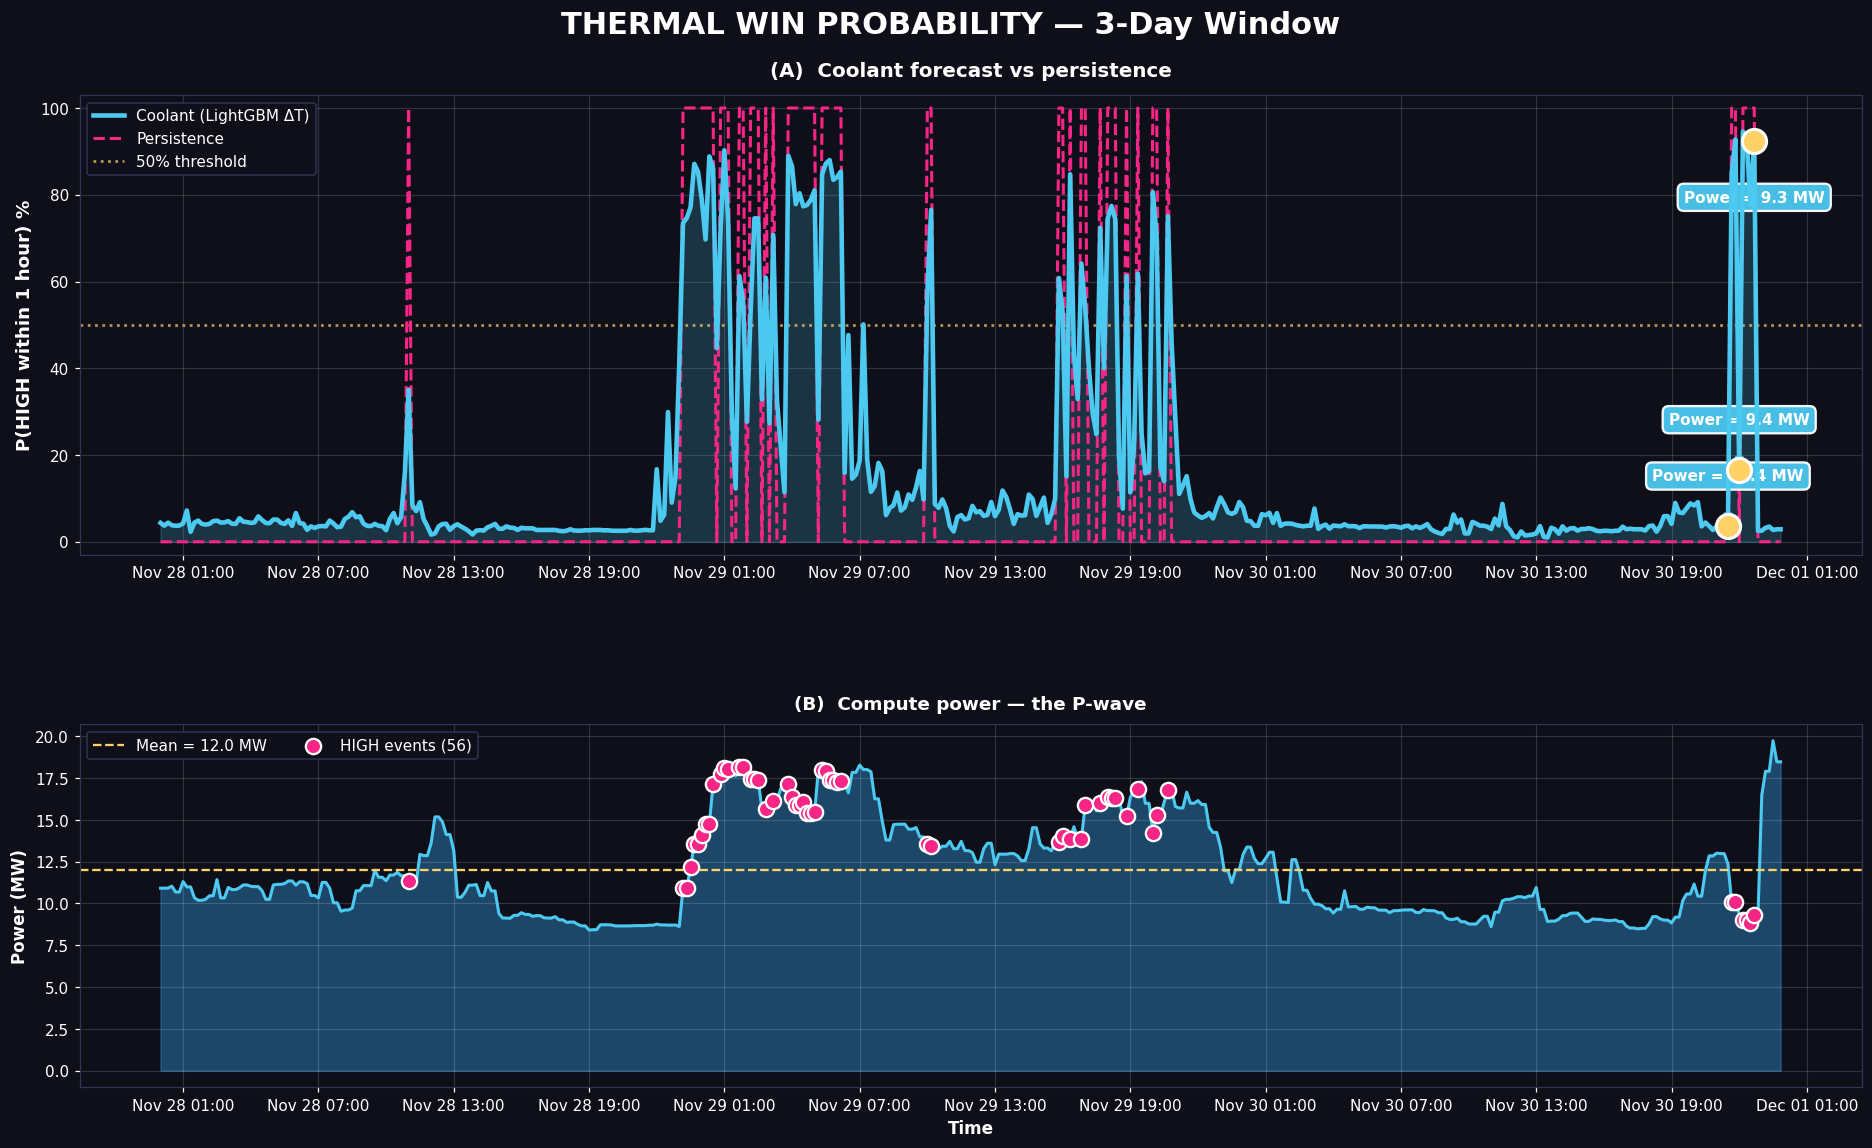

✓ Fig26 saved (56 HIGH events in window)


In [5]:
test_df = pd.DataFrame({"timestamp":timestamps,"T_obs":T_obs_arr,"T_hat":T_hat,"power":power_arr})
test_df["date"] = test_df["timestamp"].dt.date
high_by_day = test_df.groupby("date")["T_obs"].apply(lambda x: (x>HIGH_THRESH).sum())
peak_idx = test_df[test_df["date"]==high_by_day.idxmax()].index[0]
start = max(0, peak_idx-144); end = min(len(test_df), peak_idx+288)
window = test_df.iloc[start:end].reset_index(drop=True)

X_w = test.iloc[start:end]
T_hat_w = tier_forecast(X_w)
val_residuals = np.load(MODEL_DIR/"coolant_tier_val_residuals.npy")
cdf = lambda v: np.searchsorted(val_residuals, v, side="right")/len(val_residuals)
p_high = 1.0 - cdf(HIGH_THRESH - T_hat_w)
p_persist = (window["T_obs"].values > HIGH_THRESH).astype(float)

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor("#0f0f1a")
fig.suptitle("THERMAL WIN PROBABILITY — 3-Day Window",
             fontsize=20, fontweight="bold", y=0.97, color="white")

ax = fig.add_axes([0.06, 0.52, 0.90, 0.38]); ax.set_facecolor("#0f0f1a")
for s in ax.spines.values(): s.set_color("#333355")
t_w = window["timestamp"]
ax.plot(t_w, p_high*100, lw=3, color="#4cc9f0", label="Coolant (LightGBM ΔT)", zorder=4)
ax.fill_between(t_w, 0, p_high*100, color="#4cc9f0", alpha=0.20, zorder=2)
ax.plot(t_w, p_persist*100, lw=2, color="#f72585", ls="--",
        label="Persistence", zorder=3)
ax.axhline(50, color="#ffd166", ls=":", lw=1.8, alpha=0.7, label="50% threshold")

diffs = np.abs(np.diff(p_high))
for idx in np.argsort(diffs)[-3:]:
    pct = p_high[idx]*100
    ax.scatter([t_w[idx]], [pct], s=250, c="#ffd166", edgecolor="white", linewidth=2, zorder=10)
    ax.annotate(f"Power = {window['power'].values[idx]:.1f} MW",
                (t_w[idx], pct), xytext=(0, 30 if pct<50 else -40), textcoords="offset points",
                fontsize=10, fontweight="bold", color="white", ha="center",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="#4cc9f0",
                          edgecolor="white", linewidth=1.5, alpha=0.95),
                arrowprops=dict(arrowstyle="->", color="#4cc9f0", lw=2))

ax.set_ylim(-3, 103); ax.set_ylabel("P(HIGH within 1 hour) %",
                                     fontsize=12, fontweight="bold", color="white")
ax.set_title("(A)  Coolant forecast vs persistence", fontsize=13, fontweight="bold", color="white", pad=12)
ax.tick_params(colors="white")
ax.legend(loc="upper left", fontsize=10, facecolor="#0f0f1a", edgecolor="#333355", labelcolor="white")
ax.grid(True, alpha=0.15, color="white")
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d %H:%M"))

ax = fig.add_axes([0.06, 0.08, 0.90, 0.30], sharex=ax); ax.set_facecolor("#0f0f1a")
for s in ax.spines.values(): s.set_color("#333355")
ax.fill_between(t_w, window["power"].values, color="#2c7fb8", alpha=0.5)
ax.plot(t_w, window["power"].values, lw=2, color="#4cc9f0")
ax.axhline(window["power"].mean(), color="#ffd166", ls="--", lw=1.5,
           label=f"Mean = {window['power'].mean():.1f} MW")
high_mask = window["T_obs"].values > HIGH_THRESH
if high_mask.any():
    ax.scatter(t_w[high_mask], window["power"].values[high_mask], s=100,
               c="#f72585", edgecolor="white", linewidth=1.5, zorder=10,
               label=f"HIGH events ({high_mask.sum()})")
ax.set_ylabel("Power (MW)", fontsize=11, fontweight="bold", color="white")
ax.set_xlabel("Time", fontsize=11, fontweight="bold", color="white")
ax.set_title("(B)  Compute power — the P-wave", fontsize=12, fontweight="bold", color="white", pad=10)
ax.tick_params(colors="white")
ax.legend(loc="upper left", fontsize=10, facecolor="#0f0f1a", edgecolor="#333355", labelcolor="white", ncol=2)
ax.grid(True, alpha=0.15, color="white")

plt.savefig(FIG_DIR/"03_win_probability_chart.png", dpi=160, bbox_inches="tight", facecolor="#0f0f1a")
plt.savefig(DEST/"Fig26_Win_Probability.png", dpi=160, bbox_inches="tight", facecolor="#0f0f1a")
plt.show()
print(f"✓ Fig26 saved ({high_mask.sum()} HIGH events in window)")

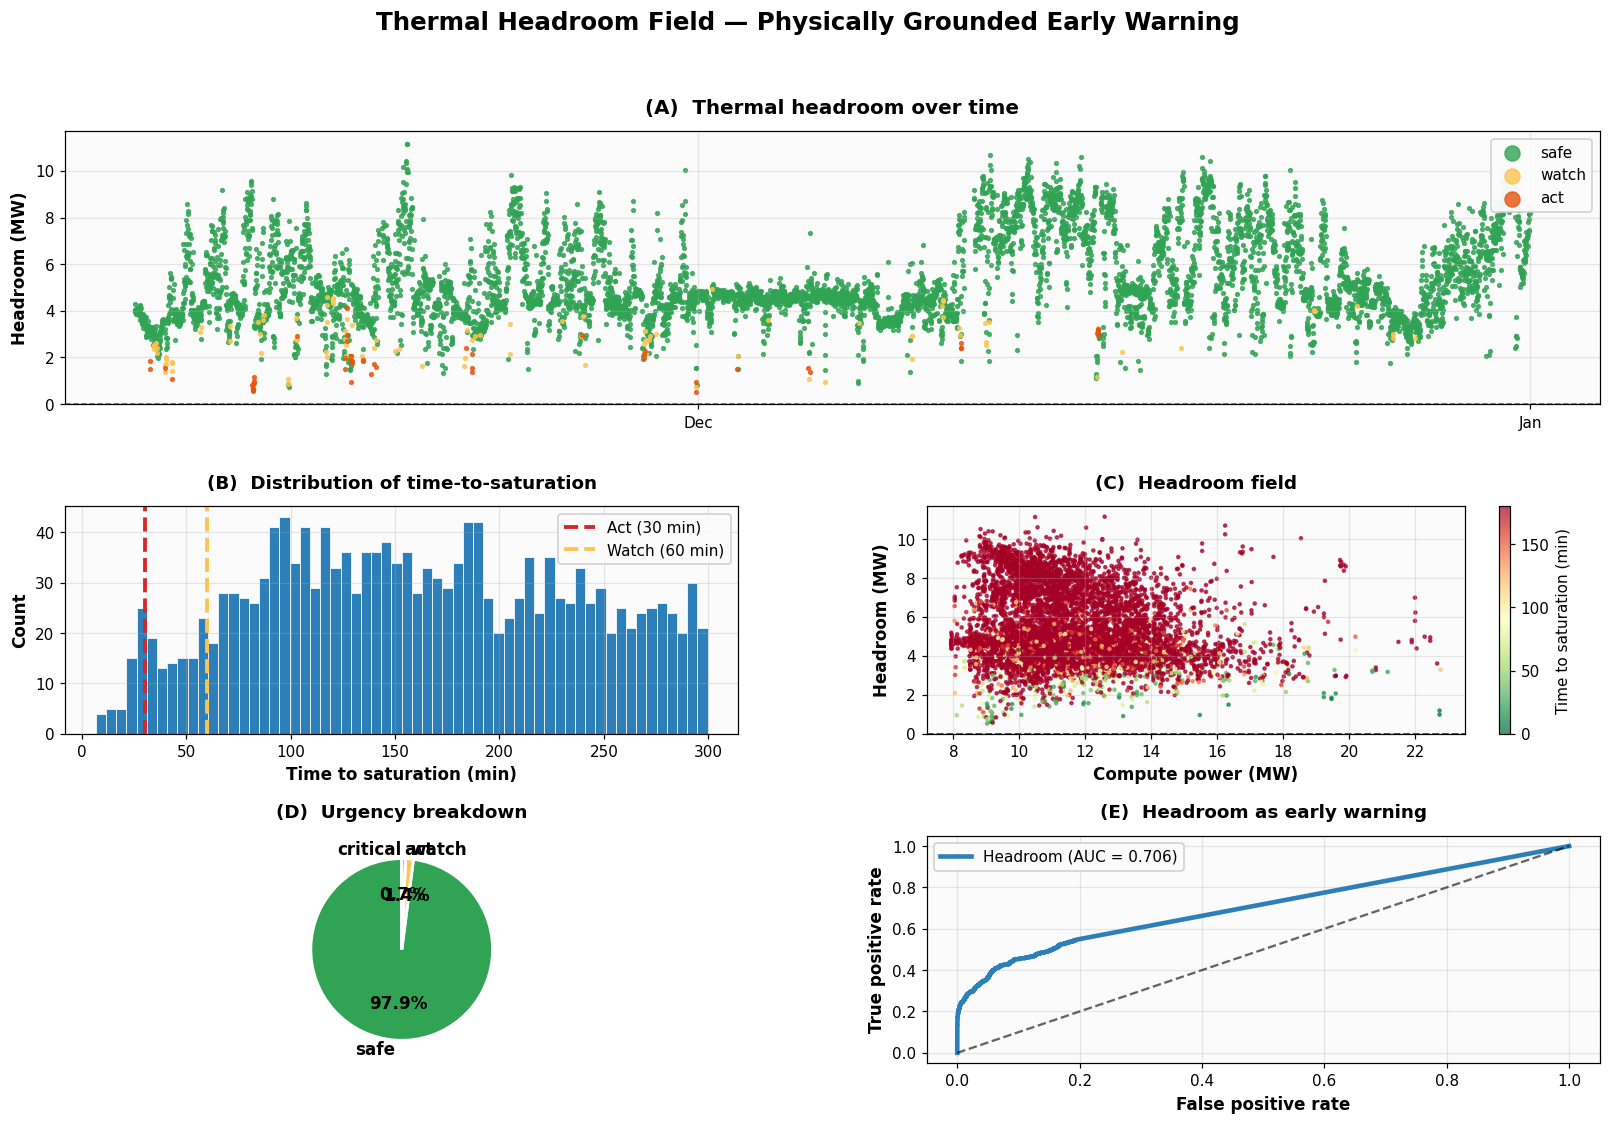

✓ Fig28 saved (AUC early warning = 0.706)


In [6]:
T_safety = HIGH_THRESH - 0.5
m_base = flow_arr * GPM_TO_KGS
m_max = m_base * MAX_SCALE
Q_rem_max = m_max * CP * (T_safety - T_sup_arr) / 1e6
headroom = Q_rem_max - Q_arr

dQ = np.r_[0, np.diff(Q_arr)]
dQ_smooth = pd.Series(dQ).rolling(6, min_periods=1).mean().values
tts = np.where(dQ_smooth > 0.01, headroom / np.maximum(dQ_smooth, 0.01) * DT_MIN, 999)
tts = np.clip(tts, 0, 300)

urgency = np.full(len(headroom), "safe", dtype=object)
urgency[(tts < 60) & (headroom > 0)] = "watch"
urgency[(tts < 30) & (headroom > 0)] = "act"
urgency[headroom <= 0] = "critical"
counts = pd.Series(urgency).value_counts()

fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(3, 2, hspace=0.42, wspace=0.28,
                       height_ratios=[1.2, 1.0, 1.0])

colors_u = {"safe":PALETTE["success"], "watch":PALETTE["warning"],
             "act":PALETTE["accent"], "critical":PALETTE["danger"]}

ax = fig.add_subplot(gs[0, :])
for cat in ["safe","watch","act","critical"]:
    mask = urgency == cat
    if mask.any():
        ax.scatter(timestamps[mask], headroom[mask], s=6,
                   c=colors_u[cat], label=cat, alpha=0.8)
ax.axhline(0, color="black", lw=1, ls="--", alpha=0.6)
ax.set_ylabel("Headroom (MW)", fontsize=11, fontweight="bold")
ax.set_title("(A)  Thermal headroom over time", fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="upper right", fontsize=10, markerscale=4)
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[1, 0])
finite = tts[tts < 300]
ax.hist(finite, bins=60, color=PALETTE["primary"], edgecolor="white", linewidth=0.5)
ax.axvline(30, color=PALETTE["danger"], ls="--", lw=2.5, label="Act (30 min)")
ax.axvline(60, color=PALETTE["warning"], ls="--", lw=2.5, label="Watch (60 min)")
ax.set_xlabel("Time to saturation (min)", fontsize=11, fontweight="bold")
ax.set_ylabel("Count", fontsize=11, fontweight="bold")
ax.set_title("(B)  Distribution of time-to-saturation", fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[1, 1])
sc = ax.scatter(power_arr, headroom, c=tts, cmap="RdYlGn_r", s=4, alpha=0.7, vmin=0, vmax=180)
ax.axhline(0, color="black", ls="--", lw=1.2, alpha=0.7)
cb = fig.colorbar(sc, ax=ax); cb.set_label("Time to saturation (min)", fontsize=10)
ax.set_xlabel("Compute power (MW)", fontsize=11, fontweight="bold")
ax.set_ylabel("Headroom (MW)", fontsize=11, fontweight="bold")
ax.set_title("(C)  Headroom field", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[2, 0])
cats = ["safe","watch","act","critical"]
sizes = [counts.get(c,0) for c in cats]
ax.pie(sizes, labels=cats, autopct=lambda p: f"{p:.1f}%" if p>0.5 else "",
       colors=[colors_u[c] for c in cats],
       wedgeprops=dict(edgecolor="white", linewidth=2),
       textprops=dict(fontsize=11, fontweight="bold"), startangle=90)
ax.set_title("(D)  Urgency breakdown", fontsize=12, fontweight="bold")

ax = fig.add_subplot(gs[2, 1])
high_mask = (T_obs_arr > HIGH_THRESH).astype(int)
high_30 = maximum_filter1d(high_mask, size=3)
fpr, tpr, _ = roc_curve(high_30, -tts)
auc_head = roc_auc_score(high_30, -tts)
ax.plot(fpr, tpr, lw=3, color=PALETTE["primary"], label=f"Headroom (AUC = {auc_head:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1.5, alpha=0.6)
ax.set_xlabel("False positive rate", fontsize=11, fontweight="bold")
ax.set_ylabel("True positive rate", fontsize=11, fontweight="bold")
ax.set_title("(E)  Headroom as early warning", fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.suptitle("Thermal Headroom Field — Physically Grounded Early Warning",
             fontsize=16, fontweight="bold", y=0.98)
plt.savefig(FIG_DIR/"05_thermal_headroom.png", dpi=160, bbox_inches="tight")
plt.savefig(DEST/"Fig28_Thermal_Headroom.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"✓ Fig28 saved (AUC early warning = {auc_head:.3f})")

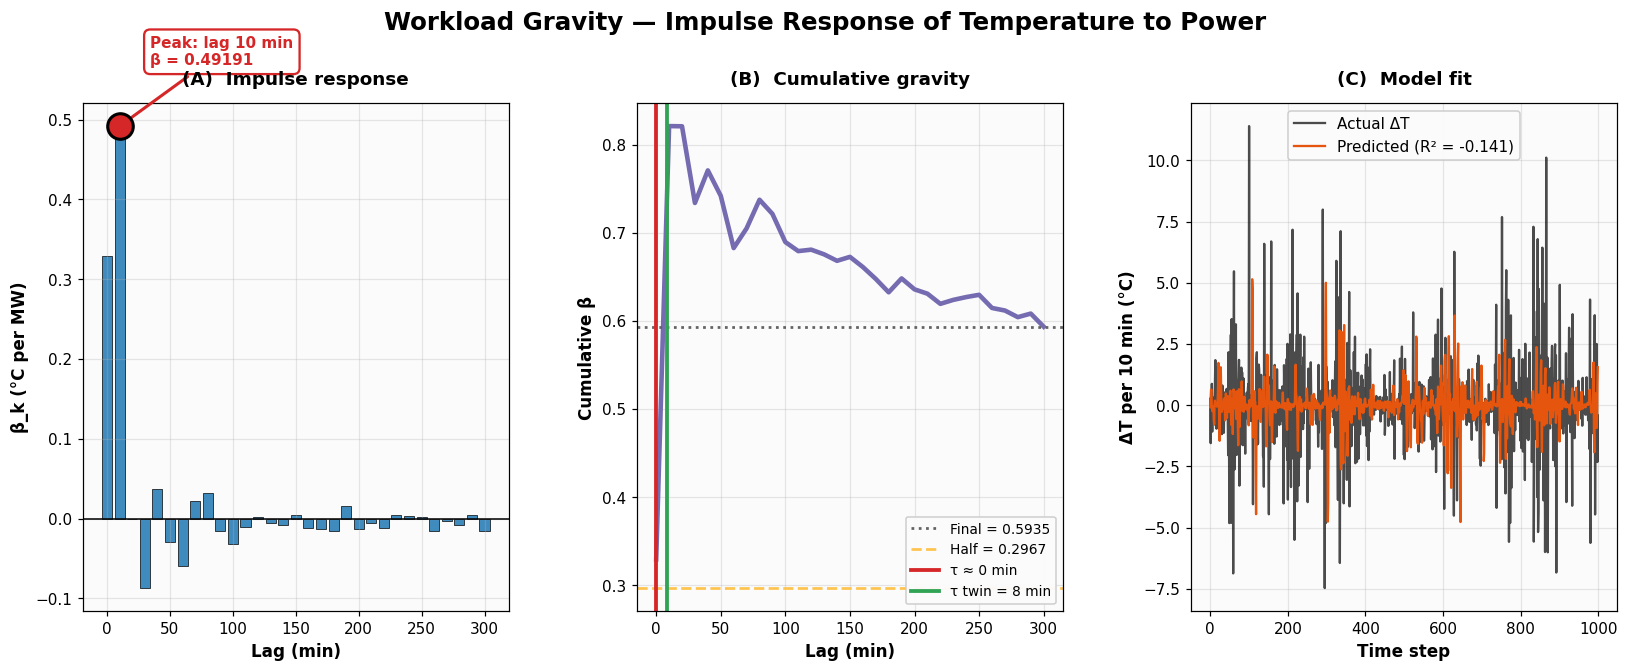

✓ Fig27 saved (peak lag 10 min, τ_IRF = 0 min, R²=-0.141)


In [7]:
K = 30
ramp_full = np.r_[0, np.diff(power_arr)]
dT_full   = np.r_[0, np.diff(T_obs_arr)]

train_ramp = np.r_[0, np.diff(train["compute_MW"].values)]
train_dT   = np.r_[0, np.diff(train["T_ret_C"].values)]

def build_lag(target, driver, K):
    n = len(target)
    Y = target[K:]
    X = np.zeros((n-K, K+1))
    for k in range(K+1):
        X[:, k] = driver[K-k:n-k]
    return X, Y

X_tr, Y_tr = build_lag(train_dT, train_ramp, K)
reg = Ridge(alpha=1.0).fit(X_tr, Y_tr)
beta = reg.coef_

X_te, Y_te = build_lag(dT_full, ramp_full, K)
Y_pred = reg.predict(X_te)
r2_irf = r2_score(Y_te, Y_pred)

cum_irf = np.cumsum(beta)
peak_idx = int(np.argmax(np.abs(beta)))
peak_beta = beta[peak_idx]
final_cum = cum_irf[-1] if abs(cum_irf[-1])>1e-6 else 1e-6
half_idx = int(np.argmax(np.abs(cum_irf) > abs(final_cum/2)))
tau_irf = half_idx * DT_MIN

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 3, wspace=0.30)

ax = fig.add_subplot(gs[0,0])
lags_min = np.arange(K+1)*DT_MIN
ax.bar(lags_min, beta, width=8, color=PALETTE["primary"], edgecolor="black", linewidth=0.5, alpha=0.9)
ax.axhline(0, color="black", lw=1)
ax.scatter([lags_min[peak_idx]], [peak_beta], s=280, c=PALETTE["danger"], edgecolor="black", linewidth=2, zorder=10)
ax.annotate(f"Peak: lag {peak_idx*DT_MIN} min\nβ = {peak_beta:.5f}",
            (lags_min[peak_idx], peak_beta), xytext=(20,40), textcoords="offset points",
            fontsize=10, fontweight="bold", color=PALETTE["danger"],
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=PALETTE["danger"], linewidth=1.5),
            arrowprops=dict(arrowstyle="->", color=PALETTE["danger"], lw=2))
ax.set_xlabel("Lag (min)", fontsize=11, fontweight="bold")
ax.set_ylabel("β_k (°C per MW)", fontsize=11, fontweight="bold")
ax.set_title("(A)  Impulse response", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[0,1])
ax.plot(lags_min, cum_irf, lw=3, color=PALETTE["purple"])
ax.axhline(final_cum, color=PALETTE["neutral"], ls=":", lw=1.8, label=f"Final = {final_cum:.4f}")
ax.axhline(final_cum/2, color=PALETTE["warning"], ls="--", lw=1.8, label=f"Half = {final_cum/2:.4f}")
ax.axvline(lags_min[half_idx], color=PALETTE["danger"], lw=2.5, label=f"τ ≈ {tau_irf} min")
ax.axvline(TAU_MIN, color=PALETTE["success"], ls="-", lw=2.5, label=f"τ twin = {TAU_MIN:.0f} min")
ax.set_xlabel("Lag (min)", fontsize=11, fontweight="bold")
ax.set_ylabel("Cumulative β", fontsize=11, fontweight="bold")
ax.set_title("(B)  Cumulative gravity", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="lower right"); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[0,2])
sample = slice(500, 1500)
ax.plot(Y_te[sample], lw=1.5, color="black", label="Actual ΔT", alpha=0.7)
ax.plot(Y_pred[sample], lw=1.5, color=PALETTE["accent"], label=f"Predicted (R² = {r2_irf:.3f})")
ax.set_xlabel("Time step", fontsize=11, fontweight="bold")
ax.set_ylabel("ΔT per 10 min (°C)", fontsize=11, fontweight="bold")
ax.set_title("(C)  Model fit", fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.suptitle("Workload Gravity — Impulse Response of Temperature to Power",
             fontsize=16, fontweight="bold", y=1.02)
plt.savefig(FIG_DIR/"04_workload_gravity.png", dpi=160, bbox_inches="tight")
plt.savefig(DEST/"Fig27_Workload_Gravity.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"✓ Fig27 saved (peak lag {peak_idx*DT_MIN} min, τ_IRF = {tau_irf} min, R²={r2_irf:.3f})")